# Часть 1

## Этап 1

In [1]:
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt 
import seaborn as sns
import mlflow
import os
from dotenv import load_dotenv

load_dotenv()

TRACKING_SERVER_HOST = os.environ['TRACKING_SERVER_HOST']
TRACKING_SERVER_PORT = os.environ['TRACKING_SERVER_PORT']
MLFLOW_TRACKING_URI = f"http://{TRACKING_SERVER_HOST}:{TRACKING_SERVER_PORT}"

EXPERIMENT_NAME = os.environ['EXPERIMENT_NAME']
RUN_NAME = 'eda_research'

mlflow.set_tracking_uri(MLFLOW_TRACKING_URI)
mlflow.set_registry_uri(MLFLOW_TRACKING_URI)

/home/mle-user/mle_projects/mle-uplift-yeda/venv/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
df = pd.read_csv('uplift_fp_data.csv')

df.head()

,recency,history_segment,history,mens,womens,zip_code,newbie,channel,treatment,target
0,10,1,142.44,1,0,1,0,1,1,0
1,6,2,329.08,1,1,2,1,2,0,0
2,7,1,180.65,0,1,1,1,2,1,0
3,9,4,675.83,1,0,2,1,2,0,0
4,2,0,45.34,1,0,0,0,2,1,0


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 64000 entries, 0 to 63999
Data columns (total 10 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   recency          64000 non-null  int64  
 1   history_segment  64000 non-null  int64  
 2   history          64000 non-null  float64
 3   mens             64000 non-null  int64  
 4   womens           64000 non-null  int64  
 5   zip_code         64000 non-null  int64  
 6   newbie           64000 non-null  int64  
 7   channel          64000 non-null  int64  
 8   treatment        64000 non-null  int64  
 9   target           64000 non-null  int64  
dtypes: float64(1), int64(9)
memory usage: 4.9 MB


In [5]:
print("nans by columns")
for col in df.columns:
    print(f"{col}: {df[col].isna().sum()} {df[col].isnull().sum()}")

nans by columns
recency: 0 0
history_segment: 0 0
history: 0 0
mens: 0 0
womens: 0 0
zip_code: 0 0
newbie: 0 0
channel: 0 0
treatment: 0 0
target: 0 0


## Этап 2

### EDA


In [3]:
ASSETS_DIR = 'eda_assets'

sns.set_palette('muted')

Размер тестовой и контрольной групп

In [6]:
df.groupby('treatment').size()

treatment
0    42613
1    21387
dtype: int64

In [18]:
df.groupby('target').size()

target
0    54606
1     9394
dtype: int64

In [20]:
df.groupby(['target', 'treatment']).size().reset_index()

,target,treatment,0
0,0,0,36457
1,0,1,18149
2,1,0,6156
3,1,1,3238


Проверяем баланс групп по каждому признаку

In [ ]:
def check_balance(df, features, treatment_col='treatment'):
    balance_report = []
    for col in features:
        if df[col].nunique() <= 5:
            stats = df.groupby(treatment_col)[col].value_counts(normalize=True).unstack()
        else:
            stats = df.groupby(treatment_col)[col].mean()
        print(f"--- Balance for {col} ---")
        print(stats)
        print("\n")

features = ['recency', 'history', 'mens', 'womens', 'zip_code', 'newbie', 'channel']
check_balance(df, features)

--- Balance for recency ---
treatment
0    5.761669
1    5.767850
Name: recency, dtype: float64


--- Balance for history ---
treatment
0    241.859315
1    242.536633
Name: history, dtype: float64


--- Balance for mens ---
mens              0         1
treatment                    
0          0.447915  0.552085
1          0.451068  0.548932


--- Balance for womens ---
womens            0         1
treatment                    
0          0.450473  0.549527
1          0.449899  0.550101


--- Balance for zip_code ---
zip_code          0         1         2
treatment                              
0          0.401403  0.448830  0.149767
1          0.400056  0.451209  0.148735


--- Balance for newbie ---
newbie            0         1
treatment                    
0          0.498252  0.501748
1          0.496750  0.503250


--- Balance for channel ---
channel           0         1         2
treatment                              
0          0.121630  0.435712  0.442658
1          0.120

Заметен небольшой дисбаланс в размерах тестовой и контрольной группы и целевых действий в этих группах

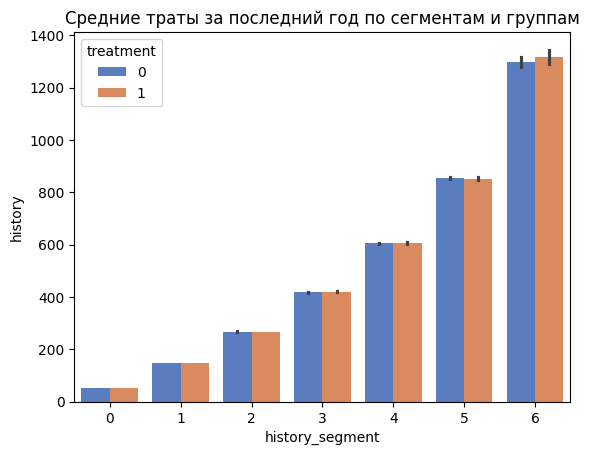

In [65]:
sns.barplot(
    df,
    x='history_segment',
    y='history',
    hue='treatment',
    estimator='mean'
)

plt.title("Средние траты за последний год по сегментам и группам")

plt.savefig(f"{ASSETS_DIR}/mean_history_by_segments.png")

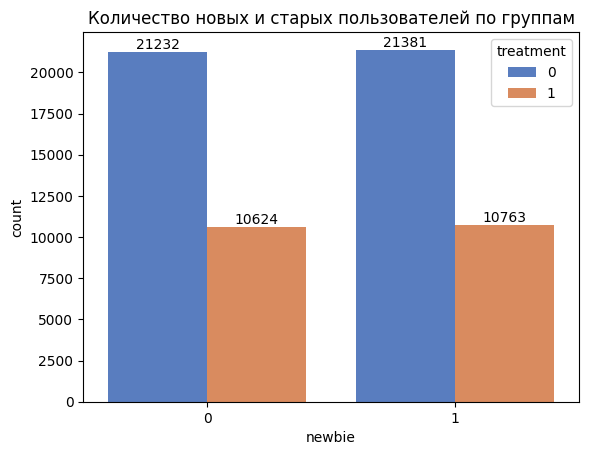

In [66]:
agg = df.groupby(['newbie', 'treatment']).size().reset_index().rename(columns={0: 'count'})

ax = sns.barplot(
    agg,
    x='newbie',
    y='count',
    hue='treatment'
)
for container in ax.containers:
    ax.bar_label(container, fontsize=10)

plt.title("Количество новых и старых пользователей по группам")

plt.savefig(f"{ASSETS_DIR}/newbie_distribution.png")

In [4]:
test = df[df['treatment'] == 1]
control = df[df['treatment'] == 0]

Сравнение уровня uplift по сегментам

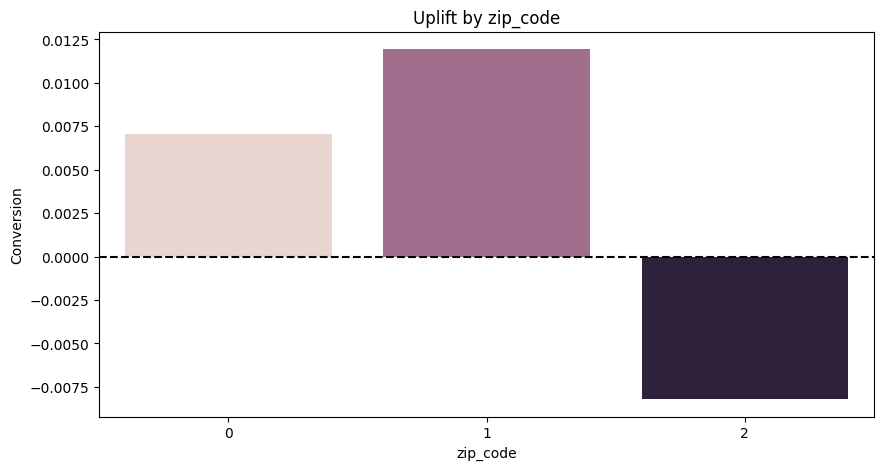

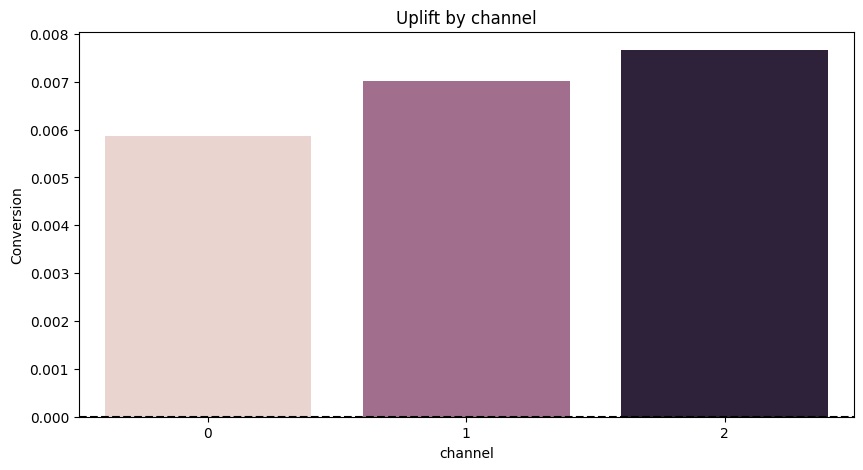

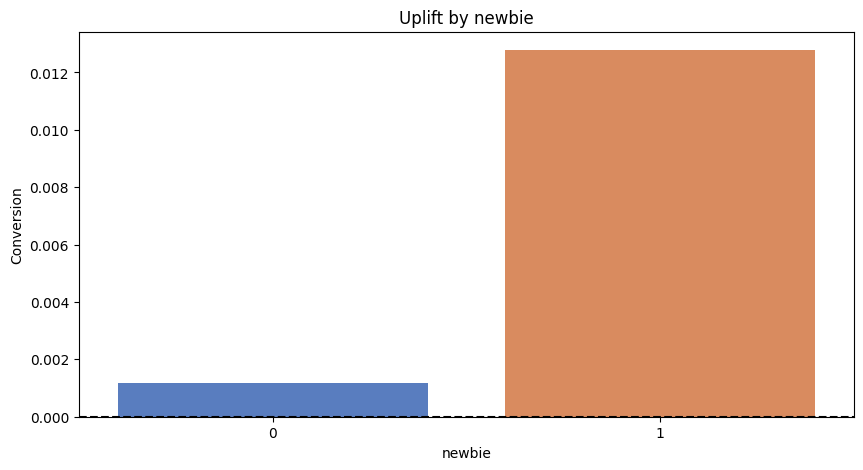

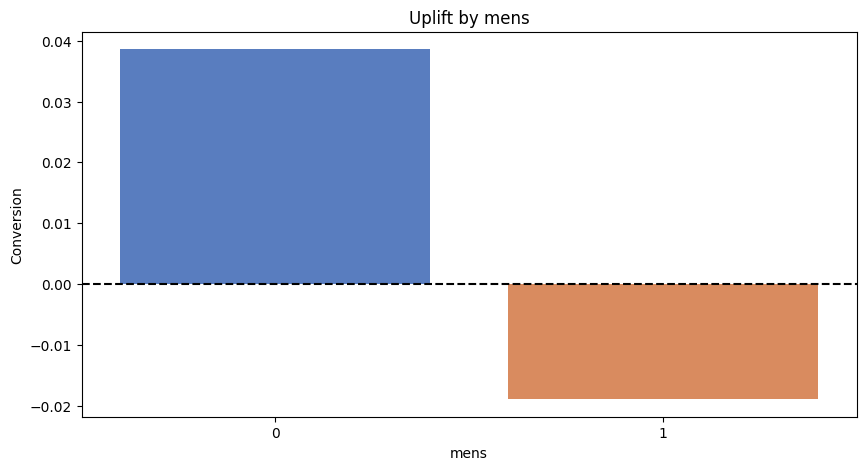

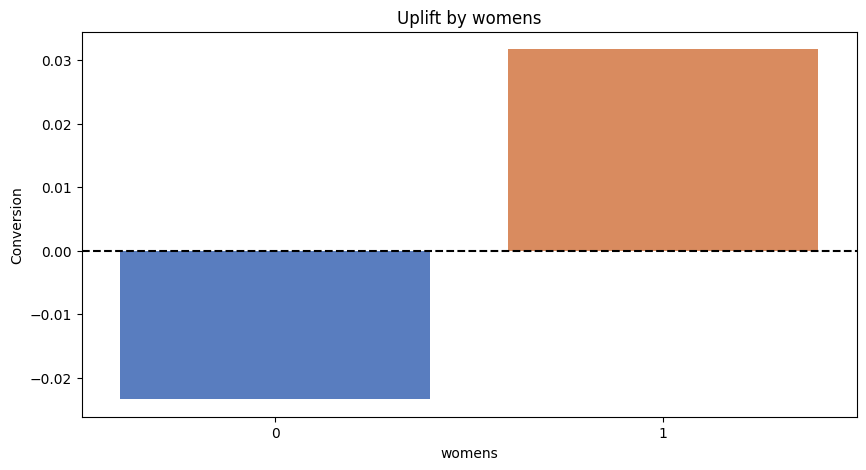

In [70]:
def plot_uplift_by_category(df, col, treatment_col='treatment', target_col='target'):
    summary = df.groupby([col, treatment_col])[target_col].agg(['mean', 'std', 'count']).reset_index()
    
    pivot = summary.pivot(index=col, columns=treatment_col, values='mean')
    uplift = pivot[1] - pivot[0]
    
    plt.figure(figsize=(10, 5))
    sns.barplot(x=uplift.index, y=uplift.values, hue=uplift.index, legend=False, errorbar='ci')
    plt.axhline(0, color='black', linestyle='--')
    plt.title(f'Uplift by {col}')
    plt.ylabel('Conversion')

    plt.savefig(f"{ASSETS_DIR}/uplift_by_{col}.png")

    plt.show()

for cat_col in ['zip_code', 'channel', 'newbie', 'mens', 'womens']:
    plot_uplift_by_category(df, cat_col)

Сравнение конверсии групп для непрерывных переменных

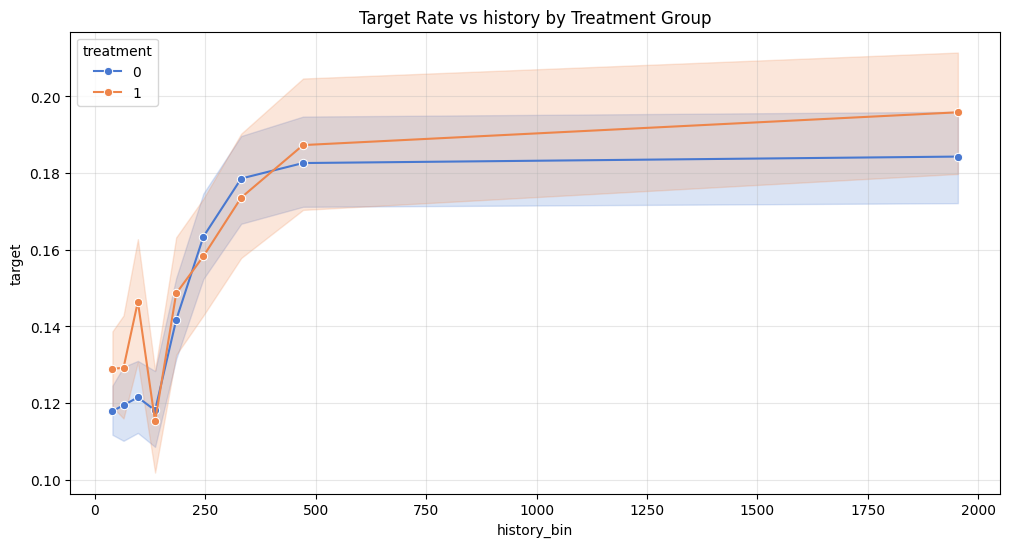

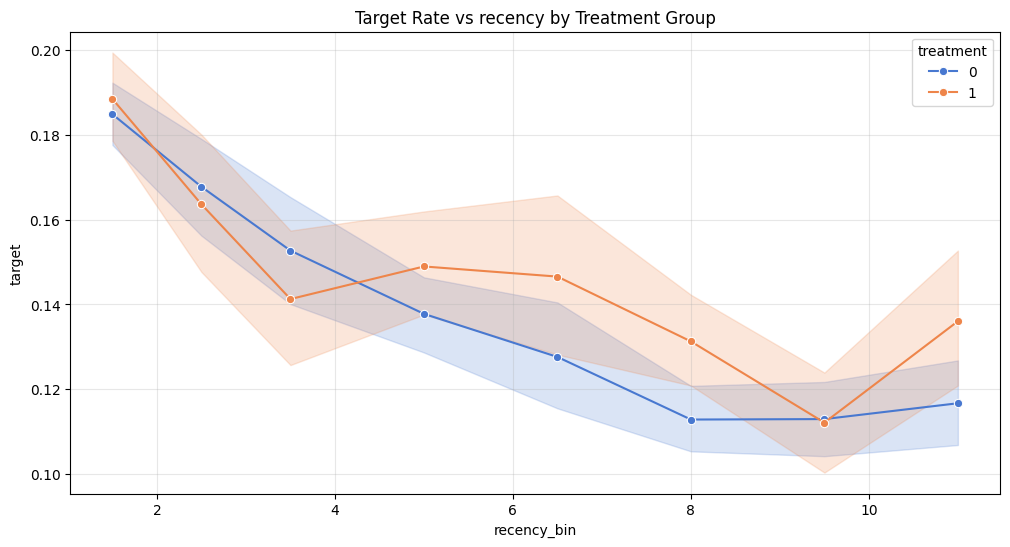

In [28]:
def plot_interaction(df, col, bins=10):
    df_temp = df.copy()
    df_temp[f'{col}_bin'] = pd.qcut(df[col], q=bins, duplicates='drop').apply(lambda x: x.mid)
    
    plt.figure(figsize=(12, 6))
    sns.lineplot(data=df_temp, x=f'{col}_bin', y='target', hue='treatment', marker='o')
    plt.title(f'Target Rate vs {col} by Treatment Group')
    plt.grid(True, alpha=0.3)
    plt.savefig(f"{ASSETS_DIR}/target_rate_{col}.png")
    plt.show()

plot_interaction(df, 'history')
plot_interaction(df, 'recency')

По ценовым сегментам скидка дает сильно положительный эффект в первых трех бинах. В следующих прослеживается отрицательный эффект за исключением последнего

Положительный uplift прослеживается в группе пользователей с 5-9 месяцами с последней покупки. Так же эффектр продолжает расти и после 10 месяцев отсутствия активности

Propensity Score AUC: 0.5495


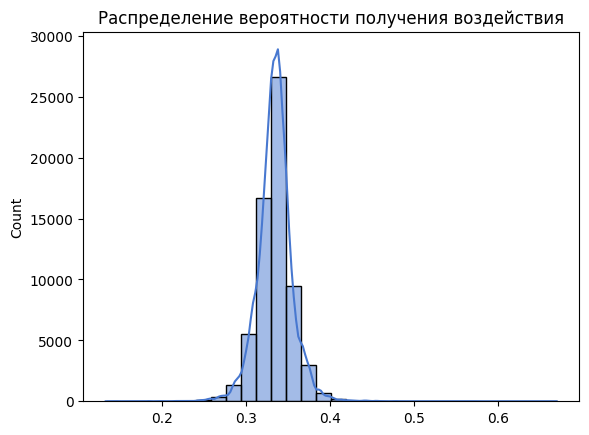

In [73]:
from xgboost import XGBClassifier
from sklearn.metrics import roc_auc_score

X_p = df.drop(['target', 'treatment', 'history_segment'], axis=1)
y_p = df['treatment']

prop_model = XGBClassifier(n_estimators=50, max_depth=3)
prop_model.fit(X_p, y_p)

preds = prop_model.predict_proba(X_p)[:, 1]
auc = roc_auc_score(y_p, preds)

print(f"Propensity Score AUC: {auc:.4f}")

sns.histplot(preds, bins=30, kde=True)
plt.title("Распределение вероятности получения воздействия")
plt.savefig(f"{ASSETS_DIR}/treatment_propensity_distribution.png")
plt.show()

In [29]:
experiment_id = mlflow.set_experiment(EXPERIMENT_NAME).experiment_id

with mlflow.start_run(run_name='eda_research', experiment_id=experiment_id) as run:
    mlflow.log_artifacts(ASSETS_DIR)
    mlflow.log_artifact('uplift_project.ipynb')

🏃 View run eda_research at: http://127.0.0.1:5000/#/experiments/7/runs/10d8a998fe6744f5b2ff4577c1aafca3
🧪 View experiment at: http://127.0.0.1:5000/#/experiments/7


### Вывод на основе EDA
1. В объеме данных нет сильного дисбаланса по количеству записей, а по признакам группы распределены идеально
2. Выдача промокода сильно снижает конверсию в группе с мужскими товарами, а так же в селах (с индексом 2)
3. Для новых пользователей конверсия сильно выше (в 12 раз), чем для старых пользователей. Для старых пользователей она находится на очень низком уровне
4. Выдача промокода дает наибольший эффект в ценовой группе до 150$ и некоторый эффект после 500$. В промежутке от 150 до 500 она оказывает скорее отрицательное воздействие
5. Промокод вызывает положительную конверсию у пользователей с периодом последней активности 5-9 месяцев и больше 10 месяцев. Лучший вариант 7 месяцев
6. Рандомизация воздействий по сегментам почти идеальная, что показывает значение AUC около 0.5

# Этап 2

### Проверка на статистическую значимость

In [18]:
test = df[df['treatment'] == 1]['target']
control = df[df['treatment'] == 0]['target']

In [19]:
stats = df.groupby('treatment')['target'].agg(['mean', 'std', 'count'])
print(stats)

               mean       std  count
treatment                           
0          0.144463  0.351563  42613
1          0.151400  0.358447  21387


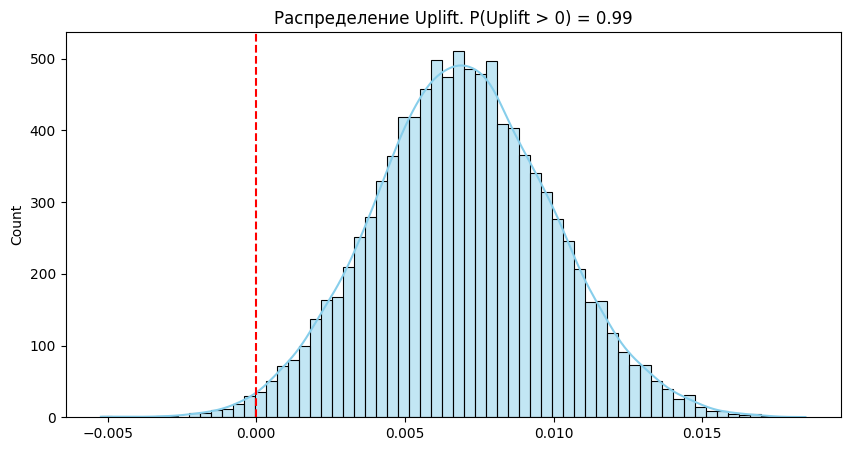

In [ ]:
def bootstrap_uplift(test_data, control_data, n_iterations=10000):
    boot_uplifts = []
    for _ in range(n_iterations):
        sample_t = np.random.choice(test_data, size=len(test_data), replace=True)
        sample_c = np.random.choice(control_data, size=len(control_data), replace=True)
        boot_uplifts.append(np.mean(sample_t) - np.mean(sample_c))
    return np.array(boot_uplifts)

boot_results = bootstrap_uplift(test['target'].values, control['target'].values)

# Вероятность того, что uplift > 0
prob_positive = (boot_results > 0).mean()

plt.figure(figsize=(10, 5))
sns.histplot(boot_results, kde=True, color='skyblue')
plt.axvline(0, color='red', linestyle='--')
plt.title(f"Распределение Uplift. P(Uplift > 0) = {prob_positive:.2f}")
plt.show()

In [ ]:
from statsmodels.stats.proportion import proportions_ztest

counts = np.array([test['target'].sum(), control['target'].sum()])
nobs = np.array([len(test), len(control)])

z_stat, p_val = proportions_ztest(counts, nobs, alternative='two-sided')

print(f"Z-score: {z_stat:.4f}")
print(f"p-value: {p_val:.4f}")

Z-score: 2.3393
p-value: 0.0193


In [ ]:
import scipy.stats as stats

p1 = test['target'].mean()
p2 = control['target'].mean()
n1 = len(test)
n2 = len(control)

se = np.sqrt(p1*(1-p1)/n1 + p2*(1-p2)/n2)

diff = p1 - p2
conf_interval = (diff - 1.96 * se, diff + 1.96 * se)

print(f"Uplift (Разница конверсий): {diff:.4f}")
print(f"95% Доверительный интервал: ({conf_interval[0]:.4f}, {conf_interval[1]:.4f})")

Uplift (Разница конверсий): 0.0069
95% Доверительный интервал: (0.0011, 0.0128)


В худшем случае в 95% случаев uplift будет не ниже 0.0011

In [ ]:
from scipy.stats import beta

# Параметры Beta-распределения (alpha - успехи, beta - неудачи)
alpha_t, beta_t = 1 + test['target'].sum(), 1 + len(test) - test['target'].sum()
alpha_c, beta_c = 1 + control['target'].sum(), 1 + len(control) - control['target'].sum()

samples = 100000
test_posterior = beta.rvs(alpha_t, beta_t, size=samples)
control_posterior = beta.rvs(alpha_c, beta_c, size=samples)

prob_win = (test_posterior > control_posterior).mean()

print(f"Вероятность того, что промокод эффективен: {prob_win * 100:.2f}%")

Вероятность того, что промокод эффективен: 98.99%


In [22]:
from scipy import stats

t_stat, t_p_value = stats.ttest_ind(test, control, equal_var=False)

u_stat, u_p_value = stats.mannwhitneyu(test, control, alternative='two-sided')

print(f"T-тест:     stat={t_stat:.4f}, p-value={t_p_value:.4f}")
print(f"Манн-Уитни: stat={u_stat:.4f}, p-value={u_p_value:.4f}")

T-тест:     stat=2.3244, p-value=0.0201
Манн-Уитни: stat=458843376.5000, p-value=0.0193


Для анализа выбран t-тест для независимых выборок. Несмотря на то, что целевая переменная бинарная, объем выборки позволяет опираться на Центральную Предельную Теорему, согласно которой распределение средних значений будет стремиться к нормальному. Согласно тесту значение Z равно 2.32, что выше чем 1.96 и позволяет считать тест статистически значимым

## Построение корреляций

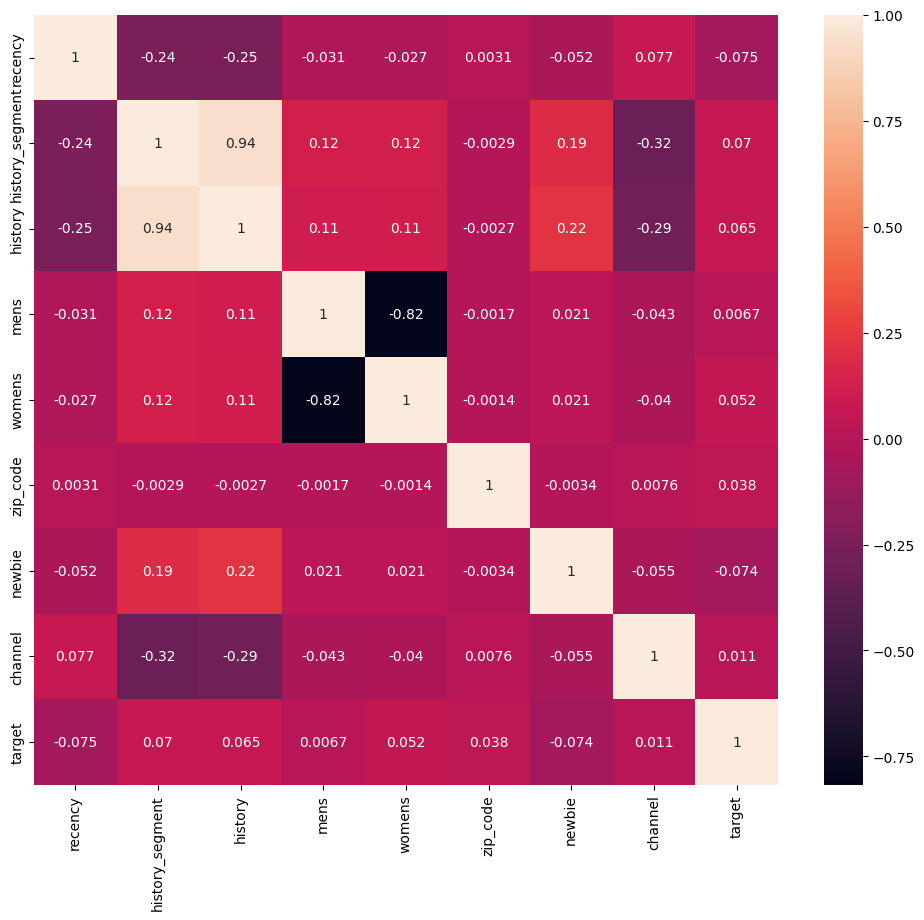

In [ ]:
plt.figure(figsize=(12, 10))
sns.heatmap(df.drop('treatment', axis=1).corr(), annot=True)
plt.title('Корреляция признаков')
plt.show()

1. Признаки `history` и `history_segment` имеют полную корреляцию между собой, потому что один признак сделан на основе другого.
2. Признаки `mens` и `womens` имеют отрицательную корреляцию, потому что это просто бинарные признаки и очевидно зачастую один исключает другой.
3. У признака `mens` нет почти никакой корреляции с целевой переменной, из-за чего в принципе можно не рассматривать мужчин как целевую аудиторию

## Этап 3

Обоснуйте выбор конкретной uplift модели в данной ячейке

### Советы по обучению и инференсу моделей
1. Некоторые uplift модели из библиотеки `causalml` будут требовать категориальные значения воздействия. Для этого используйте маппинг
#### Пример использования маппинга
```python
treatment_mapping = {
    0: 'control',
    1: 'treatment'
}
treatment_train_mapped = treatment_train.map(treatment_mapping)
treatment_test_mapped = treatment_test.map(treatment_mapping)
```

2. При вызове метода `.predict` и получения метрик для тестовой выборки не забывайте применять к прогнозам метод `squeeze()`, чтобы преобразовать многомерный массив в одномерный, что поможет получить адекватные метрики.

3. Для воспроизводимости результатов и объективной оценки не забывайте применять `random_state=42` для моделей, а также при разделении выборки

### Разбиение выборки на тренировочную и тестовую

### Обучение выбранного бейзлайна

### Расчет метрик для выбранного бейзлайна на тестовой выборке

# Обучение 2 моделей 

### Обучение модели 1

### Получение метрик по модели 1

### Обучение модели 2

### Получение метрик по модели 2

Проинтерпретируйте полученные результаты и обоснуйте выбор 1 модели в этой ячейке

# Часть 2

## Этап 1
Улучшите бейзлайн выбранной модели

#### Генерация признаков (опционально)

### Подбор гиперпараметров

In [ ]:
from optuna import create_study
from sklift.metrics import uplift_at_k

def objective(trial):
    # Дополните код для подбора гиперпараметров

    uplift_at_30 = uplift_at_k(y_test, uplift_pred, treatment_test, k=0.3, strategy='overall')
    return uplift_at_30

# Создаем и запускаем исследование
study = create_study(direction='maximize')
study.optimize(objective, n_trials=100)

# Выводим лучшие гиперпараметры
print("Best hyperparameters: ", study.best_params)
print("Best score: ", study.best_value)


## Этап 2

### Визуализация результатов

In [ ]:
from utils import custom_uplift_by_percentile

В данной ячейке сделайте вывод о качестве работы модели и проинтерпретируйте график `uplift by percentile` 

# Этап 3

In [138]:
# Класс для инференса модели
class UpliftModelInference:
    """
    Класс для инференса uplift модели.
    """
    
    def __init__(self, model, feature_names, logger=None):
        """
        Инициализация класса.
        
        Аргументы:
            model: Обученная модель uplift
            feature_names: Список признаков для предсказания 
            logger: Объект для логирования (по умолчанию None)
        """
        self.model = model
        self.feature_names = ['recency', 'history_segment', 'history', 'mens', 'womens', 'zip_code', 'newbie', 'channel']
        self.logger = logger
        
        if self.logger:
            self.logger.info("Модель UpliftModel инициализирована с признаками: %s", feature_names)

    def _transform_data(self, X):
        """
        Преобразование данных для модели.
        
        Аргументы:
            X: pandas.DataFrame с признаками
        """
        if self.logger:
            self.logger.debug("Преобразование входных данных размерности %s", X.shape)

        # реализуйте преобразование данных для модели,
        # если в финальной модели используются новые признаки
       

        return X
    
    def predict(self, X):
        """
        Получение предсказаний uplift.
        
        Аргументы:
            X: pandas.DataFrame с признаками
            
        Возвращает:
            numpy.array с предсказанными значениями uplift
        """
        # Проверяем, что датафрейм не пустой
        if X.empty:
            if self.logger:
                self.logger.error("Предоставлен пустой датафрейм")
            return None
            
        # Проверяем наличие пропущенных значений
        if X.isnull().any().any():
            if self.logger:
                self.logger.error("Входные данные содержат пропущенные значения")
            return [None]*len(X)
        
        if self.logger:
            self.logger.info("Выполняем предсказания для данных размерности %s", X.shape)

        # Проверяем наличие всех необходимых признаков
        missing_features = set(self.feature_names) - set(X.columns)
        if missing_features:
            error_msg = f"Отсутствуют признаки: {missing_features}"
            if self.logger:
                self.logger.error(error_msg)

            return [None]*len(X)
        
        # Преобразуем данные для модели
        if self.logger:
            self.logger.debug("Начинаем преобразование данных")
        X = self._transform_data(X)
        
        # Вычисляем uplift
        if self.logger:
            self.logger.debug("Выполняем предсказания модели")
        

        # Дополните код для получения предсказаний аплифта

        
        if self.logger:
            self.logger.info("Предсказания успешно завершены")
            
        return uplift


In [126]:
model = UpliftModelInference(model= # ваш код,
                             feature_names= # ваш код)

In [ ]:
test_data = pd.DataFrame({
            'recency': [1, 2, 3],
            'history_segment': [1, 2, 3], 
            'history': [100, 200, 300],
            'mens': [1, 0, 1],
            'womens': [0, 1, 0],
            'zip_code': [1, 0, 1],
            'newbie': [0, 1, 0],
            'channel': [1, 2, 0]
        })

In [ ]:
# проверка работы класса
model.predict(test_data)